TASK 3: Network Dissection on Banana Feature Maps

In [1]:
!pip install torch torchvision shap matplotlib --quiet

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


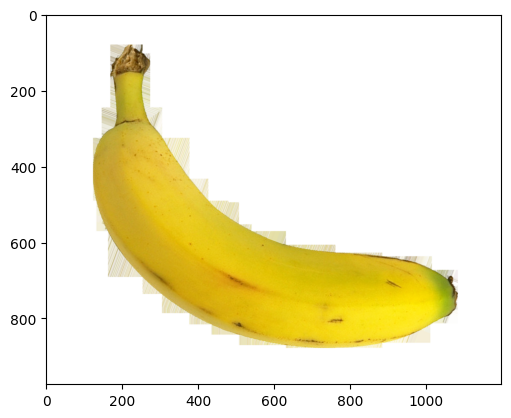

In [4]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

model = models.resnet18(pretrained=True)
model.eval()

img = Image.open('banana.png').convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

input_tensor = transform(img).unsqueeze(0)

plt.imshow(img)

In [5]:
features = []

def hook_fn(module, input, output):
    features.append(output)

model.layer4.register_forward_hook(hook_fn)

output = model(input_tensor)
feature_map = features[0].detach()

print(feature_map.shape)

torch.Size([1, 512, 7, 7])


In [6]:
avg_activation = feature_map.mean(dim=(2,3))
max_channel = avg_activation.argmax().item()
print("Max channel:", max_channel)

Max channel: 499


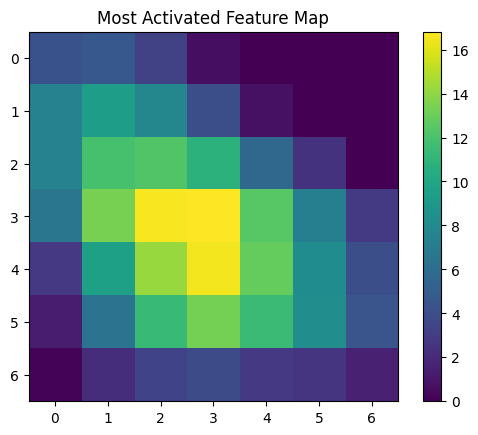

In [7]:
fm = feature_map[0, max_channel].cpu()

plt.imshow(fm, cmap='viridis')
plt.colorbar()
plt.title("Most Activated Feature Map")
plt.show()

Task 4: SHAP Explanation for Banana Image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


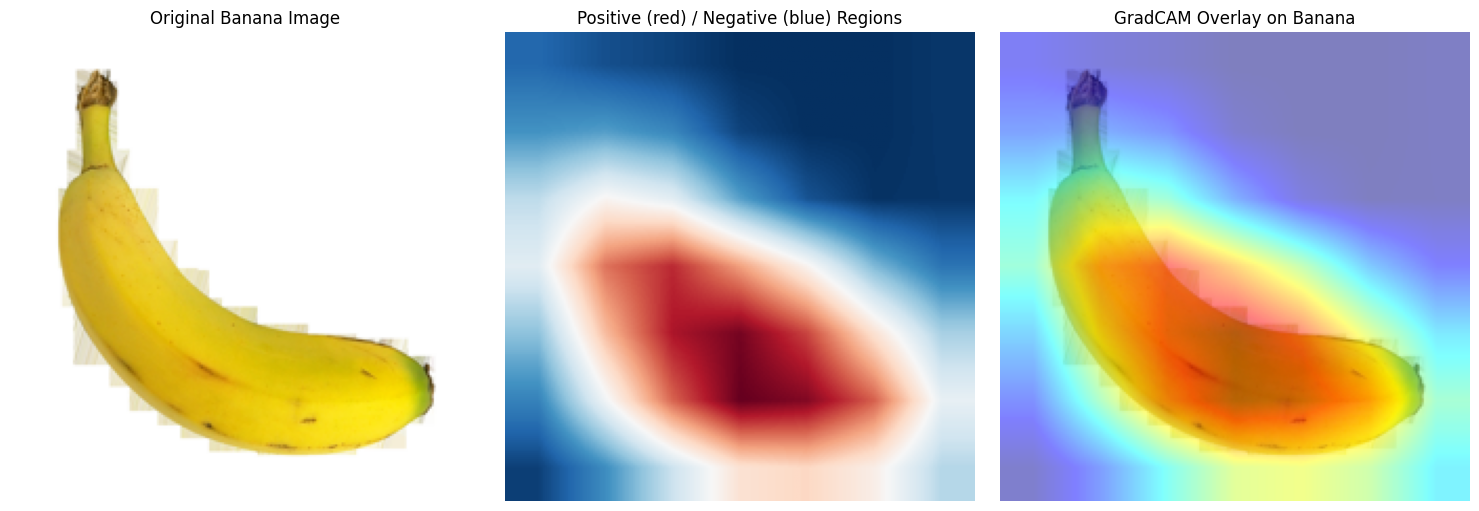

In [13]:
# Task 4: GradCAM-based Explanation for Banana Image
!pip install grad-cam --quiet

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Load model and image (reuse from Task 3)
model = models.resnet18(pretrained=True)
model.eval()

img = Image.open('banana.png').convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
input_tensor = transform(img).unsqueeze(0)

# Convert image to float numpy for overlay
img_resized = img.resize((224, 224))
img_np = np.array(img_resized) / 255.0

# Target layer = layer4 (same as Task 3)
target_layers = [model.layer4[-1]]

# Run GradCAM
cam = GradCAM(model=model, target_layers=target_layers)
grayscale_cam = cam(input_tensor=input_tensor, targets=None)
grayscale_cam = grayscale_cam[0]

# Visualize
visualization = show_cam_on_image(img_np.astype(np.float32), grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_resized)
axes[0].set_title("Original Banana Image")
axes[0].axis('off')

axes[1].imshow(grayscale_cam, cmap='RdBu_r')
axes[1].set_title("Positive (red) / Negative (blue) Regions")
axes[1].axis('off')

axes[2].imshow(visualization)
axes[2].set_title("GradCAM Overlay on Banana")
axes[2].axis('off')

plt.tight_layout()
plt.show()